# House Prices: Advanced Regression Techniques — Linear Regression Assignment


## Part 1 — Data Loading & Preprocessing

### Task 1.1 — Load Dataset

In [1]:
import numpy as np
import pandas as pd

RANDOM_STATE = 42

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Task 1.2 — Understand Data Structure

In [2]:
train.shape, test.shape

((1460, 81), (1459, 80))

**Answers:**
1. Train set: **1460 rows × 81 columns**  
   Test set: **1459 rows × 80 columns**

2. Target variable: **SalePrice**

3. Numerical and categorical features listed below:

In [3]:
target = 'SalePrice'
numeric_features = train.select_dtypes(include=['int64','float64']).columns.drop(target)
categorical_features = train.select_dtypes(include=['object']).columns
numeric_features[:10], categorical_features[:10]

(Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
        'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1'],
       dtype='object'),
 Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
        'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'],
       dtype='object'))

### Task 1.3 — Handle Missing Values

In [4]:
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [5]:
test.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageCond        78
GarageFinish      78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
dtype: int64

**Missing Value Strategy:**
- Numerical → median
- Categorical → most frequent or 'None'
- Implemented later via `SimpleImputer` inside the preprocessing pipeline.

## Part 2 — Exploratory Data Analysis (EDA)

### Task 2.1 — Visualizations

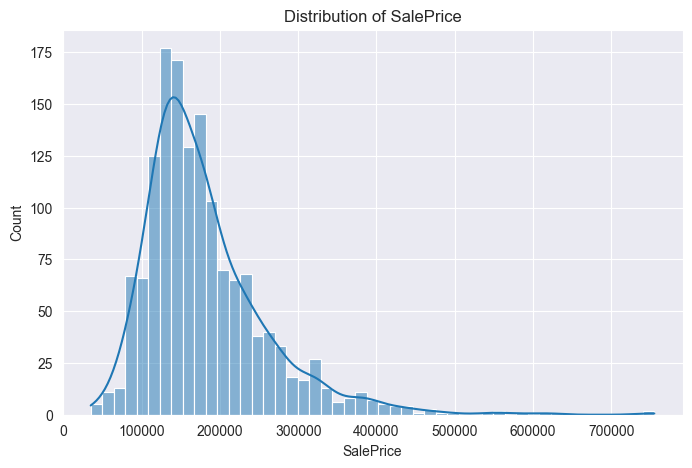

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

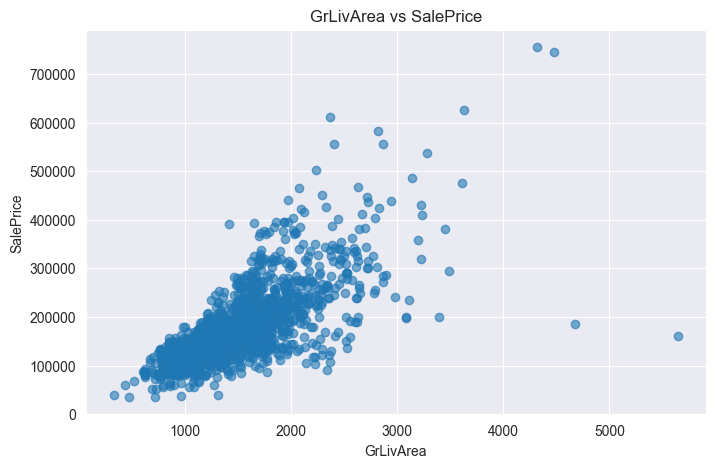

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.6)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.show()

In [8]:
corr = train.corr(numeric_only=True)
top_corr = corr['SalePrice'].sort_values(ascending=False).head(11)
top_corr

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

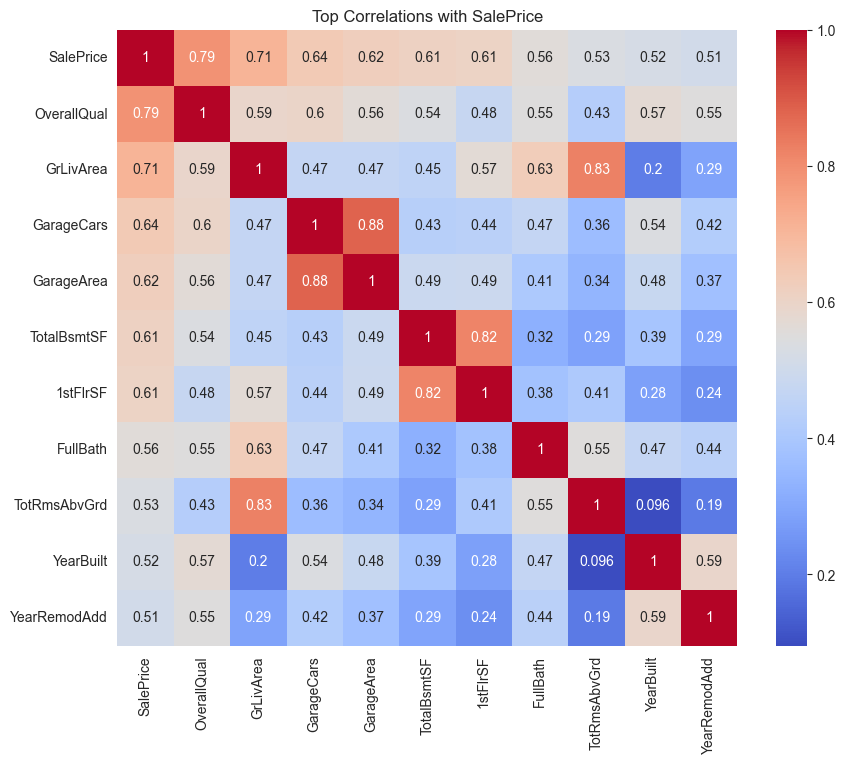

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(corr.loc[top_corr.index, top_corr.index], annot=True, cmap='coolwarm')
plt.title('Top Correlations with SalePrice')
plt.show()

**Analysis:**
- SalePrice is right-skewed → log-transform helps.
- Strongest correlations: OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF.
- Outliers present around GrLivArea > 4000.

## Part 3 — Feature Engineering

In [10]:
top_num_features = top_corr.index.drop('SalePrice')
top_num_features

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')

Categorical features will be encoded using OneHotEncoder inside a preprocessing pipeline.

## Part 4 — Train Linear Regression Model

### Task 4.1 — Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_basic = train[top_num_features]
y_basic = train[target]

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_basic, y_basic, test_size=0.2, random_state=RANDOM_STATE)
X_train_b.shape, X_val_b.shape

((1168, 10), (292, 10))

### Task 4.2 — Train the Model

In [12]:
linreg_basic = LinearRegression()
linreg_basic.fit(X_train_b, y_train_b)
y_pred_b = linreg_basic.predict(X_val_b)

### Task 4.3 — Evaluate the Model

In [13]:
mse_b = mean_squared_error(y_val_b, y_pred_b)
rmse_b = np.sqrt(mse_b)
r2_b = r2_score(y_val_b, y_pred_b)
mse_b, rmse_b, r2_b

(1558239575.1510832, np.float64(39474.54338116001), 0.7968483304281105)

### Task 4.4 — Compare Metrics

In [14]:
pd.DataFrame({'Model':['Linear Regression (Top 10 numeric)'], 'RMSE':[rmse_b], 'R2':[r2_b]})

,Model,RMSE,R2
0,Linear Regression (Top 10 numeric),39474.543381,0.796848


## Part 5 — Model for Kaggle

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

y_log = np.log1p(train[target])
ridge = RidgeCV(alphas=np.logspace(-3,3,13), cv=5)

ridge_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', ridge)
])

X_train_f, X_val_f, y_train_lg, y_val_lg = train_test_split(
    train.drop(columns=[target]), y_log, test_size=0.2, random_state=RANDOM_STATE)

ridge_model.fit(X_train_f, y_train_lg)
y_pred_lg = ridge_model.predict(X_val_f)

rmse_log = np.sqrt(mean_squared_error(y_val_lg, y_pred_lg))
y_pred_full = np.expm1(y_pred_lg)
y_true_full = np.expm1(y_val_lg)
rmse_full = np.sqrt(mean_squared_error(y_true_full, y_pred_full))
r2_full = r2_score(y_true_full, y_pred_full)
rmse_full, r2_full

(np.float64(25818.88019133905), 0.9130917569437791)

In [16]:
pd.DataFrame({
    'Model':['Linear Regression (Top 10 numeric)', 'RidgeCV + all features + log1p'],
    'RMSE':[rmse_b, rmse_full],
    'R2':[r2_b, r2_full]
})

,Model,RMSE,R2
0,Linear Regression (Top 10 numeric),39474.543381,0.796848
1,RidgeCV + all features + log1p,25818.880191,0.913092


## Part 6 — Kaggle Submission

In [17]:
ridge_model.fit(train.drop(columns=[target]), y_log)
test_pred_log = ridge_model.predict(test)
test_pred = np.expm1(test_pred_log)
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': test_pred})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,113511.784710
1,1462,144047.048460
2,1463,169180.065134
3,1464,191237.986467
4,1465,196771.143387
